In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

HOME = os.environ['HOME']
TEUFEL_DIR = HOME+'/Programming/TEUFEL'

sys.path.append(TEUFEL_DIR+'/scripts')
import teufel
import sdds
import h5py

import scipy.constants as sc
mec2 = sc.m_e*sc.c**2 / sc.e

In [2]:
!ls

chicane_beam_final.h5	    csr_dali_u300_interaction_slices.h5
chicane_beam.sdds	    csr_dali_u300_obs_10m.sdds
chicane_beam_start.h5	    CSR_InteractionField.ipynb
Chicane_testing.ipynb	    LienardWiechert.ipynb
CSR2d_testing.ipynb	    MIR_superradiance.ipynb
csr_dali_u300_beamlog.sdds


In [3]:
# open the file
hdf = h5py.File('csr_dali_u300_interaction_slices.h5', "r")
print(hdf)
print(hdf.keys())
print()
snaps = hdf['Snapshots']
print(snaps)
print(snaps.attrs.keys())
NoS = snaps.attrs.get('N_steps')
print(f'{NoS=}')
snap_data = np.array(snaps)
print(snap_data.shape)
hdf.close()

<HDF5 file "csr_dali_u300_interaction_slices.h5" (mode r)>
<KeysViewHDF5 ['Snapshots']>

<HDF5 dataset "Snapshots": shape (2000, 7), type "<f8">
<KeysViewHDF5 ['N_steps']>
NoS=2000
(2000, 7)


t = (0, 9.168426e-09) s
z = (7.153838e-06, 2.746269) m


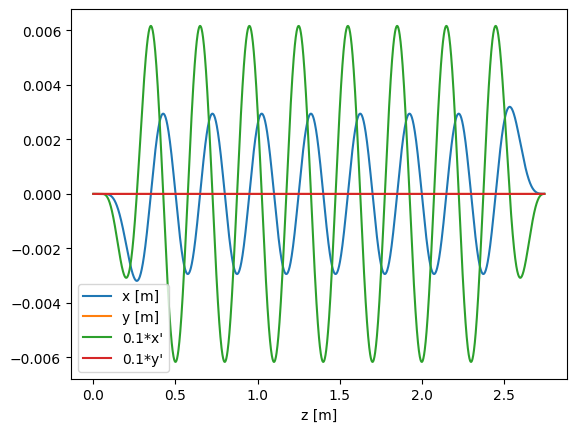

In [4]:
t = snap_data[:,0]
print(f't = ({np.min(t):.7g}, {np.max(t):.7g}) s')

x = snap_data[:,1]
y = snap_data[:,2]
z = snap_data[:,3]
print(f'z = ({np.min(z):.7g}, {np.max(z):.7g}) m')

xp = snap_data[:,4] / snap_data[:,6]
yp = snap_data[:,5] / snap_data[:,6]

plt.plot(z,x, label='x [m]')
plt.plot(z,y, label='y [m]')
plt.plot(z,0.1*xp, label="0.1*x'")
plt.plot(z,0.1*yp, label="0.1*y'")
plt.xlabel('z [m]')
plt.legend()
plt.show()